In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
import numpy as np

In [40]:
sequences = np.load("CMdata.npz")["seqs"]

min_len = 75
max_len = 95
filtered_sequences = [s for s in sequences if min_len <= len(s) <= max_len]
sequences = filtered_sequences
len(sequences)

8727

In [42]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(sequences))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'A', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'P', 14: 'Q', 15: 'R', 16: 'S', 17: 'T', 18: 'V', 19: 'W', 20: 'Y', 0: '.'}
21


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [29]:
# build the dataset
block_size = 70 # context length: how many characters do we take to predict the next one?

def build_dataset(sequences):
  X, Y = [], []

  for w in sequences:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(sequences)
#n1 = int(0.8*len(sequences))
n2 = int(0.9*len(sequences))

Xtr,  Ytr  = build_dataset(sequences[:n2])    # 90%
Xdev, Ydev = build_dataset(sequences[n2:])   # 10%


Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xdev = Xdev.to(device)
Ydev = Ydev.to(device)


torch.Size([634200, 70]) torch.Size([634200])
torch.Size([70531, 70]) torch.Size([70531])


In [30]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator(device=device).manual_seed(1) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g, device=device)

layers = [
  nn.Linear(n_embd * block_size, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, vocab_size, bias=False), nn.BatchNorm1d(vocab_size),
]

for layer in layers:
  layer.to(device)

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, nn.Linear):
      layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

import torch.optim as optim

optimizer = optim.Adam(parameters, lr=1e-4)  # Initial LR
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=150000, gamma=0.1)

82752


In [31]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

#we expect around 3, if the initialization is good the probability given to the good token is 1/20 that is e-3

train 3.04883074760437
val 3.048614978790283


In [32]:
g = torch.Generator(device=device).manual_seed(1) # for reproducibility
max_steps = 250001
batch_size = 256
lossi = []
ud = []

lri = (torch.logspace(-4,0,max_steps))


for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device = device)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  #optimizer.zero_grad()

  for p in parameters:
    p.grad = None
  loss.backward()


  # update
  #optimizer.step()
  #scheduler.step()

  lr = 0.01 if i < 150000 else 0.001 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print('epoch    ',f'{i}')
    split_loss('val')
    split_loss('train')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  #if i >= 10000:
   # break # AFTER_DEBUG: would take out obviously to run full optimization
  

# --- Saving ---

param_dict = {}
param_dict['C'] = C.detach().cpu().numpy()
for i, layer in enumerate(layers):
    for name, param in layer.named_parameters():
        param_dict[f'layer_{i}_{name}'] = param.detach().cpu().numpy()
np.savez(f'nn_parameters_{batch_size}.npz', **param_dict)


epoch     0
val 3.0480384826660156
train 3.048248291015625
epoch     10000
val 1.4114576578140259
train 1.32277250289917
epoch     20000
val 1.307104468345642
train 1.194838047027588
epoch     30000
val 1.2802646160125732
train 1.1510233879089355
epoch     40000
val 1.2583954334259033
train 1.1159082651138306
epoch     50000
val 1.2483733892440796
train 1.0925687551498413
epoch     60000
val 1.2376186847686768
train 1.0706865787506104
epoch     70000
val 1.2338306903839111
train 1.0575824975967407
epoch     80000
val 1.231238842010498
train 1.0474231243133545
epoch     90000
val 1.2272826433181763
train 1.0341631174087524
epoch     100000
val 1.2252709865570068
train 1.027278184890747
epoch     110000
val 1.2227495908737183
train 1.020045518875122
epoch     120000
val 1.2216076850891113
train 1.0116877555847168
epoch     130000
val 1.2198442220687866
train 1.0067353248596191
epoch     140000
val 1.2199769020080566
train 1.000800371170044
epoch     150000
val 1.2194530963897705
train 0.

In [46]:
# --- Loading ---
with torch.no_grad():

    loaded = np.load('nn_parameters_256_noss.npz')
    C.copy_(torch.tensor(loaded['C'], device=C.device))
    for i, layer in enumerate(layers):
        for name, param in layer.named_parameters():
            param.copy_(torch.tensor(loaded[f'layer_{i}_{name}'], device=param.device))

In [47]:
split_loss('train')
split_loss('val')

train 0.9628666043281555
val 1.206222653388977


layer 2 (      Tanh): mean +0.00, std 0.70, saturated: 11.64%
layer 5 (      Tanh): mean -0.00, std 0.70, saturated: 10.31%


Text(0.5, 1.0, 'activation distribution')

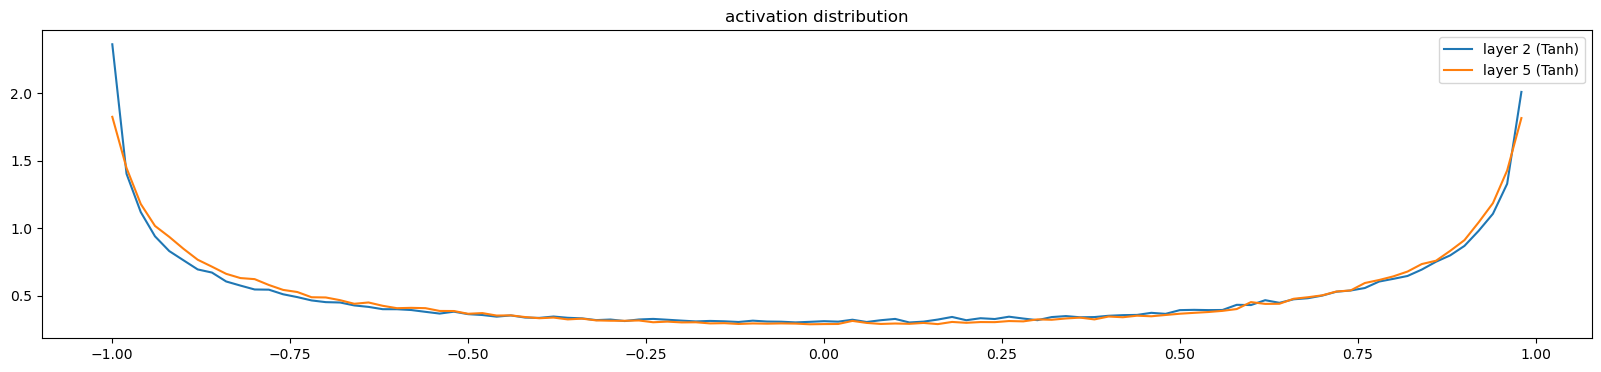

In [48]:
# visualize histograms

emb = C[Xdev] # embed the characters into vectors
x = emb.view(emb.shape[0], -1)


activations = []

for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):  # or nn.ReLU, nn.LeakyReLU, etc.
        activations.append((i, layer.__class__.__name__, x.detach().cpu().view(-1)))

# Plotting
plt.figure(figsize=(20, 4))
legends = []

for i, name, t in activations:
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title('activation distribution')


layer 2 (      Tanh): grad mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): grad mean -0.00, std 0.00, saturated: 0.00%


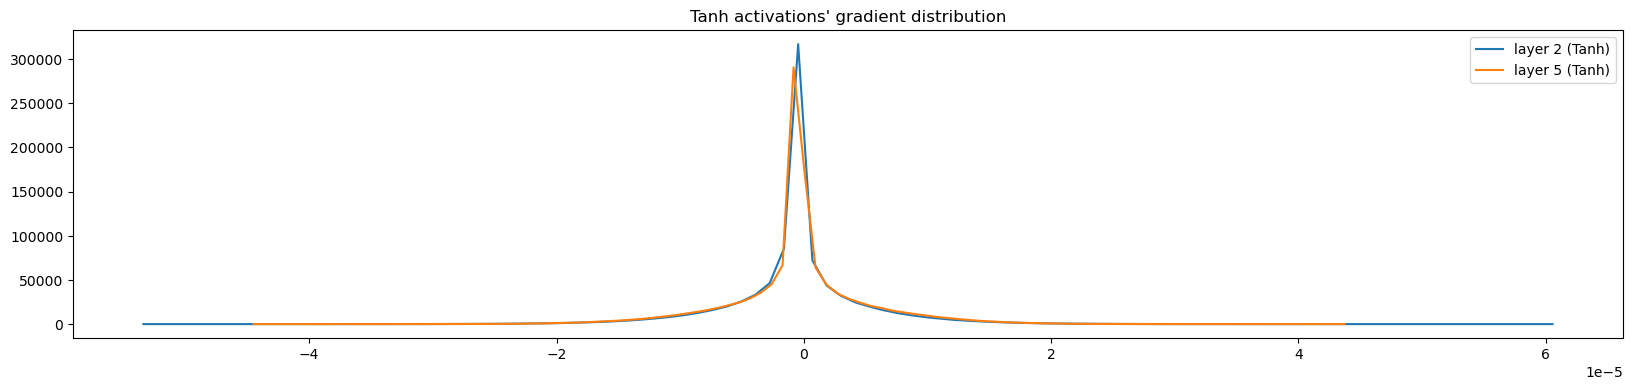

In [49]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Example dummy input
emb = C[Xdev]  # Embedding step
x = emb.view(emb.shape[0], -1)  # Flatten

activations = []

# Forward pass and retain gradients for Tanh outputs
for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):
        x.retain_grad()  # <-- retain gradient for this activation
        activations.append((i, layer.__class__.__name__, x))

# Compute loss and backward
logits = x  # Assume last x is model output
loss = F.cross_entropy(logits, Ydev)  # Assume Ydev is your target
loss.backward()

# Plotting gradients of Tanh activations
plt.figure(figsize=(20, 4))
legends = []

for i, name, act in activations:
    g = act.grad  # now it should exist
    if g is None:
        continue
    g = g.detach().cpu().view(-1)
    print('layer %d (%10s): grad mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, g.mean(), g.std(), (g.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(g, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title("Tanh activations' gradient distribution")
plt.show()

weight   (21, 10) | mean -0.000061 | std 8.875533e-03 | grad:data ratio 8.518784e-03
weight (100, 700) | mean -0.000057 | std 1.042117e-02 | grad:data ratio 2.118254e-01
weight (100, 100) | mean +0.000585 | std 1.888511e-02 | grad:data ratio 1.970147e-01
weight  (21, 100) | mean -0.000057 | std 2.418096e-02 | grad:data ratio 1.864775e-01


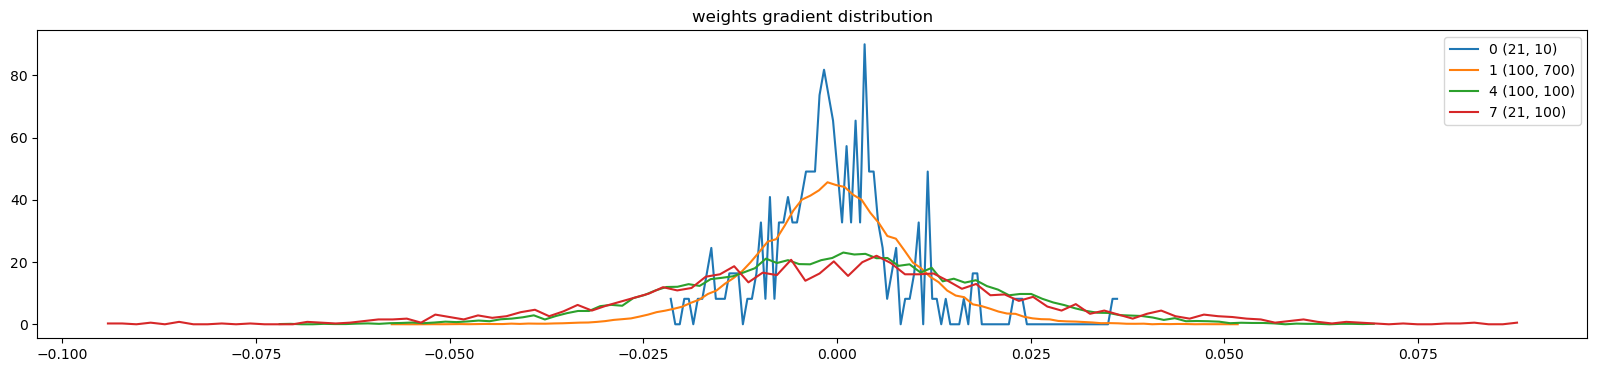

In [50]:
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
    t = p.grad
    if t is None:
        continue  # skip if grad is None (e.g., frozen layers)

    if p.ndim == 2:
        t = t.detach().cpu().view(-1)  # flatten & move to CPU
        param_std = p.std().detach().cpu()
        grad_std = t.std()
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' %
              (tuple(p.shape), t.mean(), grad_std, grad_std / param_std))

        hy, hx = torch.histogram(t, bins=100, density=True)
        plt.plot(hx[:-1].cpu(), hy.cpu())  # ensure plotting from CPU
        legends.append(f'{i} {tuple(p.shape)}')

plt.legend(legends)
plt.title('weights gradient distribution')
plt.show()


In [19]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
 if p.ndim == 2:
   plt.plot([ud[j][i] for j in range(len(ud))])
   legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

NameError: name 'ud' is not defined

<Figure size 2000x400 with 0 Axes>

In [51]:
g = torch.Generator(device=device).manual_seed(0)
n = 1000

for layer in layers:
    layer.eval()

with open('generated_sequences_noss.txt', 'w') as f:
    for _ in range(n):
        out = []
        context = [0] * block_size  # initialize with all ...
        while True:
            emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # flatten
            for layer in layers:
                x = layer(x)
            logits = x
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:  # special token
                break

        sequence = ''.join(itos[i][0] for i in out[0:-1])
        header = f'>seq_{_}'
        #print(header)
        #print(sequence)
        f.write(header + '\n')
        f.write(sequence + '\n')